<a href="https://colab.research.google.com/github/nishachaudhary6396/MachineLearning/blob/Project/02_Loan_Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('hdfc_loan.csv')

In [13]:
data = df[['Loan_Amount','Loan_Term_Months','Existing_EMIs','Applicant_Income','Coapplicant_Income']].copy()
data.reset_index()

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Applicant_Income,Coapplicant_Income
0,0,8031545,360,5610,56976,0
1,1,899361,240,9166,1856,0
2,2,2387748,60,0,64553,0
3,3,658856,12,26613,88450,0
4,4,198671,36,0,9539,0
...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,0
996,996,2780228,300,20102,70886,0
997,997,301249,24,34514,24392,11337
998,998,719891,48,34000,64803,94136


In [14]:
data['Monthly Income'] = data['Applicant_Income'] + data['Coapplicant_Income']
data

,Loan_Amount,Loan_Term_Months,Existing_EMIs,Applicant_Income,Coapplicant_Income,Monthly Income
0,8031545,360,5610,56976,0,56976
1,899361,240,9166,1856,0,1856
2,2387748,60,0,64553,0,64553
3,658856,12,26613,88450,0,88450
4,198671,36,0,9539,0,9539
...,...,...,...,...,...,...
995,5883603,360,5165,44713,0,44713
996,2780228,300,20102,70886,0,70886
997,301249,24,34514,24392,11337,35729
998,719891,48,34000,64803,94136,158939


In [15]:
std_interset_rate=12
data['Annual_interest'] = (data['Loan_Amount']*std_interset_rate*1)/100
data.head()


,Loan_Amount,Loan_Term_Months,Existing_EMIs,Applicant_Income,Coapplicant_Income,Monthly Income,Annual_interest
0,8031545,360,5610,56976,0,56976,963785.40
1,899361,240,9166,1856,0,1856,107923.32
2,2387748,60,0,64553,0,64553,286529.76
3,658856,12,26613,88450,0,88450,79062.72
4,198671,36,0,9539,0,9539,23840.52


In [16]:
Bank_revenue = data['Annual_interest'].sum()
Bank_revenue

np.float64(266005548.12)

In [17]:
Existing_risk = data['Existing_EMIs'].sum()*12
Existing_risk

np.int64(218080680)

In [18]:
data['U'] = data['Annual_interest']-(data['Existing_EMIs']*12)
data

,Loan_Amount,Loan_Term_Months,Existing_EMIs,Applicant_Income,Coapplicant_Income,Monthly Income,Annual_interest,U
0,8031545,360,5610,56976,0,56976,963785.40,896465.40
1,899361,240,9166,1856,0,1856,107923.32,-2068.68
2,2387748,60,0,64553,0,64553,286529.76,286529.76
3,658856,12,26613,88450,0,88450,79062.72,-240293.28
4,198671,36,0,9539,0,9539,23840.52,23840.52
...,...,...,...,...,...,...,...,...
995,5883603,360,5165,44713,0,44713,706032.36,644052.36
996,2780228,300,20102,70886,0,70886,333627.36,92403.36
997,301249,24,34514,24392,11337,35729,36149.88,-378018.12
998,719891,48,34000,64803,94136,158939,86386.92,-321613.08


In [19]:
data['dU'] = data['U'].diff()
data['dL'] = data['Loan_Amount'].diff()
data['dU-dL'] = data['dU']/data['dL']
data

,Loan_Amount,Loan_Term_Months,Existing_EMIs,Applicant_Income,Coapplicant_Income,Monthly Income,Annual_interest,U,dU,dL,dU-dL
0,8031545,360,5610,56976,0,56976,963785.40,896465.40,NaN,NaN,NaN
1,899361,240,9166,1856,0,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983
2,2387748,60,0,64553,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900
3,658856,12,26613,88450,0,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717
4,198671,36,0,9539,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973
...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,5165,44713,0,44713,706032.36,644052.36,582583.92,5142366.0,0.113291
996,2780228,300,20102,70886,0,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758
997,301249,24,34514,24392,11337,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764
998,719891,48,34000,64803,94136,158939,86386.92,-321613.08,56405.04,418642.0,0.134733


Task 1
Create an affordability metric.
Example:
Affordability Ratio = Monthly Obligations / Monthly Income


In [21]:
data['Affordability_Ratio'] = ((data['Annual_interest']/12)+data['Existing_EMIs']) / data['Monthly Income']
data


,Loan_Amount,Loan_Term_Months,Existing_EMIs,Applicant_Income,Coapplicant_Income,Monthly Income,Annual_interest,U,dU,dL,dU-dL,Affordability_Ratio
0,8031545,360,5610,56976,0,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099
1,899361,240,9166,1856,0,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273
2,2387748,60,0,64553,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890
3,658856,12,26613,88450,0,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371
4,198671,36,0,9539,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272
...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,5165,44713,0,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374
996,2780228,300,20102,70886,0,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793
997,301249,24,34514,24392,11337,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309
998,719891,48,34000,64803,94136,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212


Task 2
Create revenue estimates for different loan ranges.


In [25]:
data['loan_Range'] = pd.cut(
    data['Loan_Amount'],
    bins=[0,10000,20000,30000,40000,np.inf],
    labels=['0-1L','1-2L','2L-3L','3L-4L','4L+']
)
revenue_by_range=data.groupby('loan_Range')['Annual_interest'].sum()
revenue_by_range

/tmp/ipykernel_7942/2764982825.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_range=data.groupby('loan_Range')['Annual_interest'].sum()


,Annual_interest
loan_Range,
0-1L,2.314440e+03
1-2L,8.276280e+03
2L-3L,9.735000e+03
3L-4L,1.631748e+04
4L+,2.659689e+08


Task 3
Create a utility function balancing:
Revenue
Affordability
Risk

U = Revenue+Affordability-Risk

In [31]:
data['Revenue_Norm'] = (
    data['Annual_interest'] - data['Annual_interest'].min()
)/ (data['Annual_interest'].max() - data['Annual_interest'].min()
)
data['Utility_Balance_Function']=data['Affordability_Ratio']-data['Revenue_Norm']
data

,Loan_Amount,Loan_Term_Months,Existing_EMIs,Applicant_Income,Coapplicant_Income,Monthly Income,Annual_interest,U,dU,dL,dU-dL,Affordability_Ratio,loan_Range,Risk,Revenue_Norm,Utility_Balance_Function
0,8031545,360,5610,56976,0,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,4L+,67320,0.582320,0.925779
1,899361,240,9166,1856,0,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,4L+,109992,0.065086,9.719187
2,2387748,60,0,64553,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,4L+,0,0.173026,0.196864
3,658856,12,26613,88450,0,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,4L+,319356,0.047644,0.327727
4,198671,36,0,9539,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,4L+,0,0.014271,0.194001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,5165,44713,0,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,4L+,61980,0.426549,1.004825
996,2780228,300,20102,70886,0,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,4L+,241224,0.201489,0.474304
997,301249,24,34514,24392,11337,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,4L+,414168,0.021710,1.028599
998,719891,48,34000,64803,94136,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,4L+,408000,0.052071,0.207141


Task 4
Compute first derivatives using numerical methods.


In [34]:
data['dU-dL'] = np.gradient(
    data['U'],
    data['Loan_Amount']
)
data['dU-dL']

,dU-dL
0,0.125983
1,0.211811
2,-0.491901
3,-0.389256
4,-0.714857
...,...
995,0.275877
996,0.184432
997,0.123552
998,0.756280


#Visualizations
Visual 1
Loan Amount Distribution


Text(0, 0.5, 'Frequency')

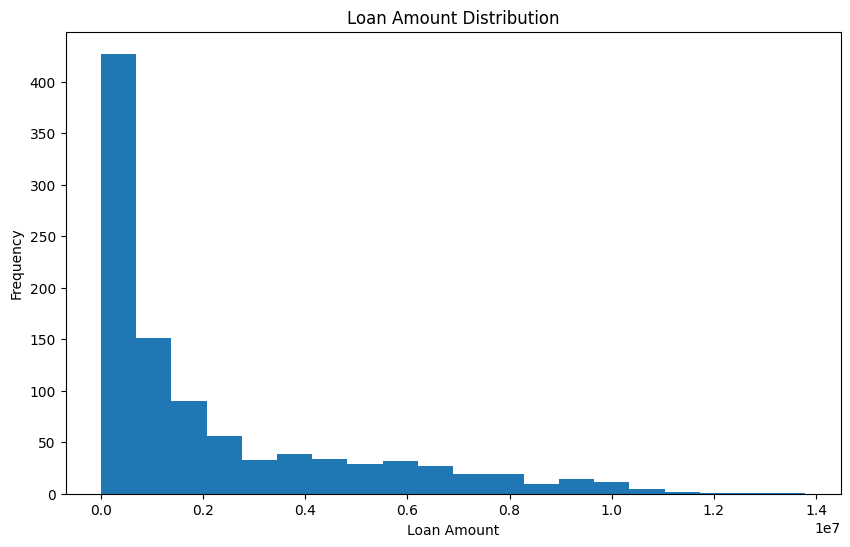

In [35]:
plt.figure(figsize=(10,6))
plt.hist(data['Loan_Amount'],bins=20)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

Visual 2
Affordability Ratio Distribution


In [38]:
clean_data = data[np.isfinite(data['Affordability_Ratio'])].copy()

clean_data['Affordability_Norm'] = (
    clean_data['Affordability_Ratio'] - clean_data['Affordability_Ratio'].min()
) / (
    clean_data['Affordability_Ratio'].max() - clean_data['Affordability_Ratio'].min()
)

Text(0, 0.5, 'Frequency')

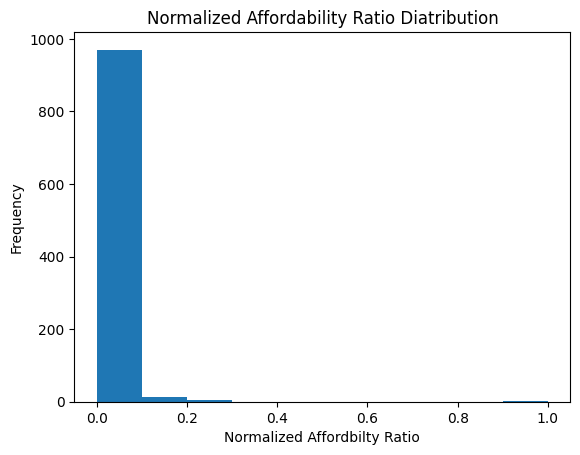

In [40]:
plt.hist(clean_data['Affordability_Norm'])
plt.title('Normalized Affordability Ratio Diatribution')
plt.xlabel('Normalized Affordbilty Ratio')
plt.ylabel('Frequency')

Visual 3
Utility Function Curve


Text(0, 0.5, 'Utility')

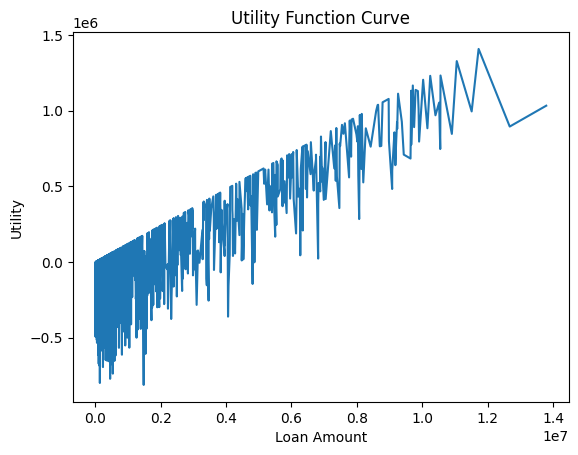

In [46]:

plt.plot(
    data['Loan_Amount'].sort_values(),
    data['U']
)
plt.title('Utility Function Curve')
plt.xlabel('Loan Amount')
plt.ylabel('Utility')